# ファイナンス理論を実際に使ってポートフォリオを設計・評価・ヘッジする
## 【Python実践】2000-2024年で訓練、2025年で検証

- 訓練期間: 2000-2024（分析・最適化・予測）
- 検証期間: 2025（答え合わせ）

## 0. 環境セットアップ

In [1]:
!pip install yfinance statsmodels -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm
import statsmodels.api as sm

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

## 1. データ取得と分割

In [3]:
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']

data_all = yf.download(tickers + ['^GSPC'], start='2000-01-01', end='2025-12-31')['Close']

train_data = data_all[data_all.index < '2025-01-01']
test_data = data_all[data_all.index >= '2025-01-01']

print(f"訓練期間: {train_data.index[0].strftime('%Y-%m-%d')} ~ {train_data.index[-1].strftime('%Y-%m-%d')} ({len(train_data)}日)")
print(f"検証期間: {test_data.index[0].strftime('%Y-%m-%d')} ~ {test_data.index[-1].strftime('%Y-%m-%d')} ({len(test_data)}日)")

train_log_returns = np.log(train_data[tickers] / train_data[tickers].shift(1)).dropna()
train_market_returns = np.log(train_data['^GSPC'] / train_data['^GSPC'].shift(1)).dropna()

/tmp/ipykernel_5656/2861078834.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_all = yf.download(tickers + ['^GSPC'], start='2000-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  6 of 6 completed


訓練期間: 2000-01-03 ~ 2024-12-31 (6289日)
検証期間: 2025-01-02 ~ 2025-12-30 (249日)


## 2. 銘柄特性の把握（リターン・リスク・相関）

=== 各銘柄の年率リターンとボラティリティ（2000-2024） ===
        Annual Return  Annual Volatility  Return/Risk
Ticker                                               
AAPL           0.2282             0.4008       0.5693
MSFT           0.0988             0.3021       0.3269
AMZN           0.1560             0.4880       0.3198
JPM            0.0931             0.3717       0.2504
JNJ            0.0718             0.1915       0.3748


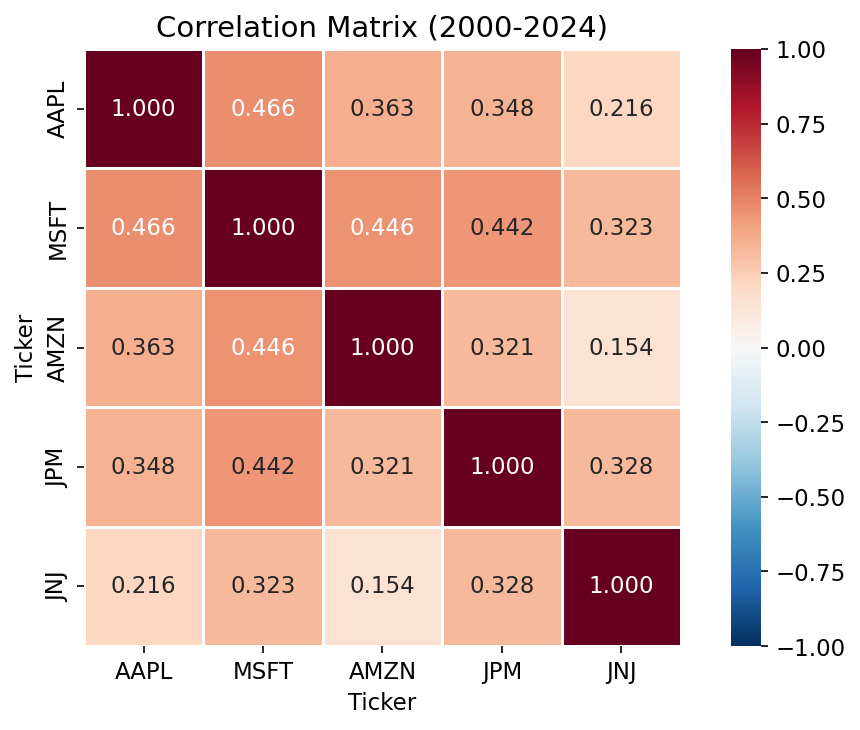

In [4]:
annual_return = train_log_returns.mean() * 252
annual_vol = train_log_returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_vol,
    'Return/Risk': annual_return / annual_vol
})
print("=== 各銘柄の年率リターンとボラティリティ（2000-2024） ===")
print(summary.round(4))

corr_matrix = train_log_returns.corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix (2000-2024)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. 市場リスクとの関係（CAPMベータ）

In [6]:
rf_annual = 0.02
rf_daily = rf_annual / 252

# 超過リターン
excess_returns = train_log_returns - rf_daily
market_excess = train_market_returns - rf_daily

# OLS回帰でベータ推定
betas = {}
r_squared = {}

for ticker in tickers:
    X = sm.add_constant(market_excess)
    model = sm.OLS(excess_returns[ticker], X).fit()
    betas[ticker] = model.params.iloc[1]
    r_squared[ticker] = model.rsquared

print("=== CAPMベータ（2000-2024） ===")
beta_df = pd.DataFrame({
    'Beta': betas,
    'R-squared': r_squared,
})
beta_df['Type'] = ['Aggressive' if b > 1 else 'Defensive' for b in beta_df['Beta']]
print(beta_df.round(4))

=== CAPMベータ（2000-2024） ===
        Beta  R-squared        Type
AAPL  1.1483     0.3095  Aggressive
MSFT  1.0995     0.4997  Aggressive
AMZN  1.2567     0.2501  Aggressive
JPM   1.4050     0.5388  Aggressive
JNJ   0.5194     0.2774   Defensive


## 4. 最適ポートフォリオの構築（マーコウィッツ）

In [7]:
mu = train_log_returns.mean().values * 252
cov = train_log_returns.cov().values * 252
n_assets = len(tickers)
investment = 1_000_000

def portfolio_performance(w, mu, cov):
    return w @ mu, np.sqrt(w @ cov @ w)

def neg_sharpe(w, mu, cov, rf):
    ret, vol = portfolio_performance(w, mu, cov)
    return -(ret - rf) / vol

result = minimize(
    neg_sharpe, x0=np.ones(n_assets) / n_assets,
    args=(mu, cov, rf_annual), method='SLSQP',
    bounds=tuple((0, 1) for _ in range(n_assets)),
    constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
)

optimal_weights = result.x
opt_ret, opt_vol = portfolio_performance(optimal_weights, mu, cov)
opt_sharpe = (opt_ret - rf_annual) / opt_vol

print("=== 最適ポートフォリオ（最大シャープレシオ） ===")
print(f"期待リターン: {opt_ret*100:.2f}%")
print(f"ボラティリティ: {opt_vol*100:.2f}%")
print(f"シャープレシオ: {opt_sharpe:.4f}")
print()
print("=== 100万円の配分 ===")
for ticker, w in zip(tickers, optimal_weights):
    print(f"  {ticker}: {w*100:.1f}% = {investment * w:,.0f}円")

=== 最適ポートフォリオ（最大シャープレシオ） ===
期待リターン: 16.14%
ボラティリティ: 25.70%
シャープレシオ: 0.5504

=== 100万円の配分 ===
  AAPL: 52.7% = 526,859円
  MSFT: 0.0% = 0円
  AMZN: 8.6% = 86,090円
  JPM: 0.0% = 0円
  JNJ: 38.7% = 387,051円


### 図1: 効率的フロンティアと最適ポートフォリオ

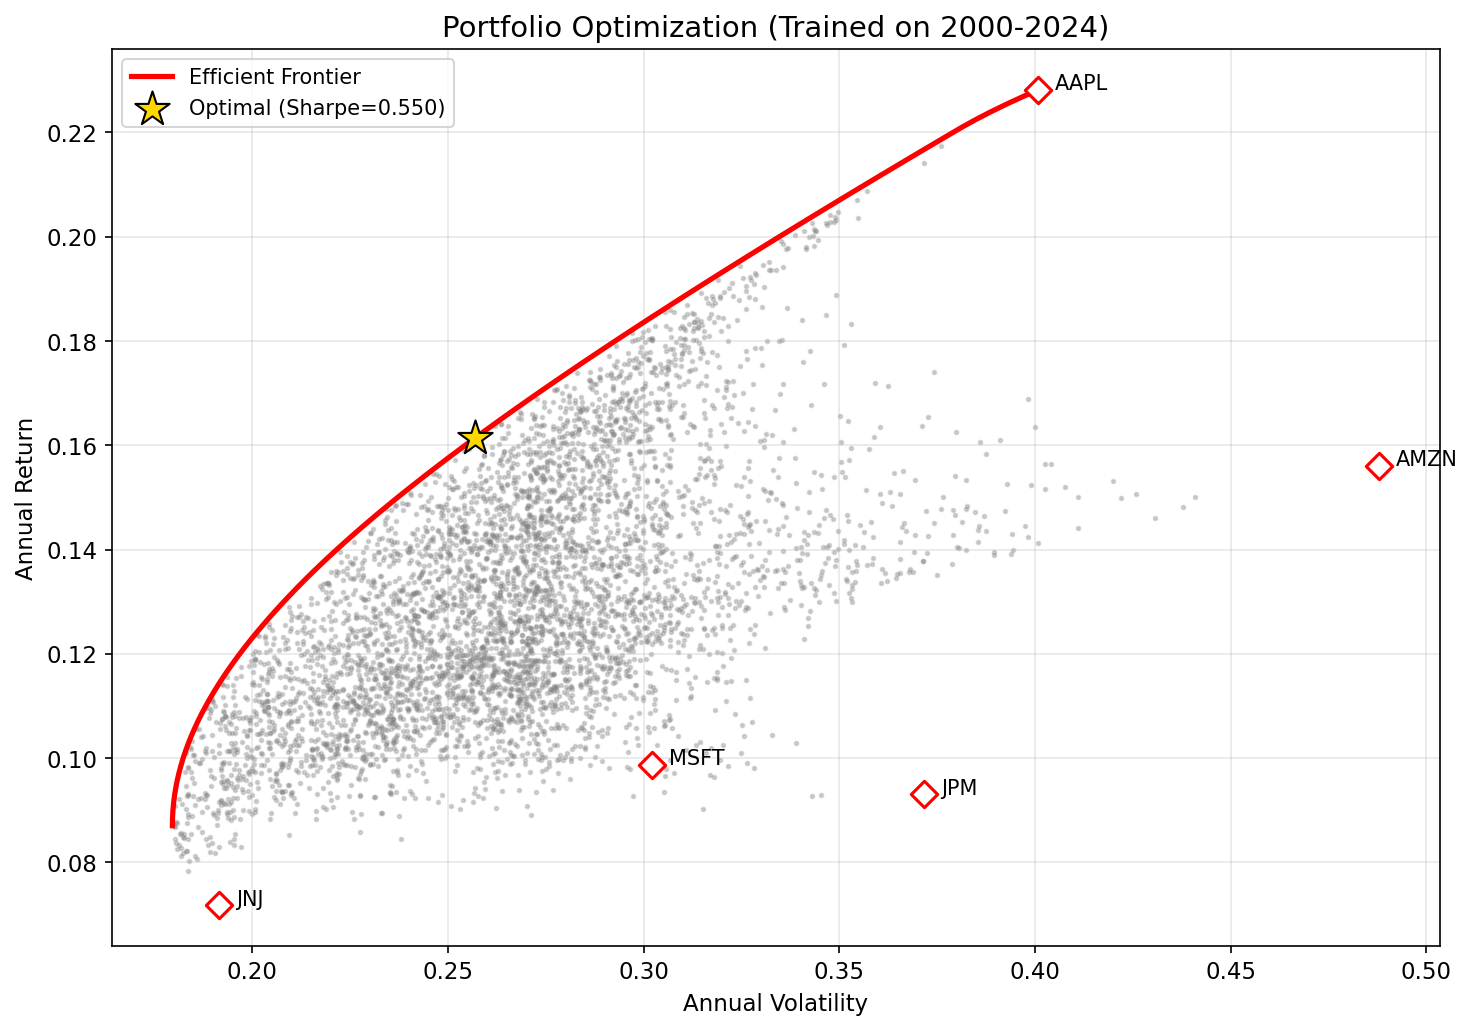

In [8]:
gmvp_result = minimize(
    lambda w: w @ cov @ w, x0=np.ones(n_assets) / n_assets, method='SLSQP',
    bounds=tuple((0, 1) for _ in range(n_assets)),
    constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
)
gmvp_ret, gmvp_vol = portfolio_performance(gmvp_result.x, mu, cov)

target_returns = np.linspace(gmvp_ret, mu.max(), 100)
efficient_vols = []
for target in target_returns:
    res = minimize(
        lambda w: w @ cov @ w, x0=np.ones(n_assets) / n_assets, method='SLSQP',
        bounds=tuple((0, 1) for _ in range(n_assets)),
        constraints=[
            {'type': 'eq', 'fun': lambda w: w @ mu - target},
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        ]
    )
    efficient_vols.append(np.sqrt(res.x @ cov @ res.x) if res.success else np.nan)

np.random.seed(42)
rand_results = np.zeros((5000, 2))
for i in range(5000):
    w = np.random.dirichlet(np.ones(n_assets))
    r, v = portfolio_performance(w, mu, cov)
    rand_results[i] = [v, r]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(rand_results[:, 0], rand_results[:, 1], s=3, alpha=0.3, c='gray')
ax.plot(efficient_vols, target_returns, 'r-', linewidth=2.5, label='Efficient Frontier')
ax.scatter(opt_vol, opt_ret, marker='*', s=300, c='gold', edgecolors='black',
           linewidths=1, zorder=5, label=f'Optimal (Sharpe={opt_sharpe:.3f})')

for i, ticker in enumerate(tickers):
    ax.scatter(np.sqrt(cov[i, i]), mu[i], marker='D', s=80,
               edgecolors='red', facecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(ticker, (np.sqrt(cov[i, i]), mu[i]),
                textcoords="offset points", xytext=(8, 0), fontsize=10)

ax.set_title('Portfolio Optimization (Trained on 2000-2024)', fontsize=14)
ax.set_xlabel('Annual Volatility')
ax.set_ylabel('Annual Return')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 2025年のリスクをシミュレーション（モンテカルロ）

In [9]:
np.random.seed(42)
n_simulations = 10000
n_days = 252
dt = 1 / 252

mu_all = train_log_returns.mean().values * 252
sigma_all = train_log_returns.std().values * np.sqrt(252)
corr = train_log_returns.corr().values
L = np.linalg.cholesky(corr)
S0_all = train_data[tickers].iloc[-1].values

portfolio_values = np.zeros((n_days + 1, n_simulations))
portfolio_values[0] = investment

S_sim = np.zeros((n_assets, n_days + 1, n_simulations))
for k in range(n_assets):
    S_sim[k, 0] = S0_all[k]

for t_step in range(n_days):
    Z_ind = np.random.standard_normal((n_assets, n_simulations))
    Z_corr = L @ Z_ind
    daily_port_return = np.zeros(n_simulations)
    for k in range(n_assets):
        S_sim[k, t_step+1] = S_sim[k, t_step] * np.exp(
            (mu_all[k] - 0.5 * sigma_all[k]**2) * dt + sigma_all[k] * np.sqrt(dt) * Z_corr[k])
        daily_port_return += optimal_weights[k] * (S_sim[k, t_step+1] / S_sim[k, t_step] - 1)
    portfolio_values[t_step+1] = portfolio_values[t_step] * (1 + daily_port_return)

final_returns = portfolio_values[-1] / investment - 1
var_95 = -np.percentile(final_returns, 5)
cvar_95 = -np.mean(final_returns[final_returns <= -var_95])

print("=== モンテカルロ予測（2025年） ===")
print(f"1年後のポートフォリオ価値:")
print(f"  平均: {portfolio_values[-1].mean():,.0f}円")
print(f"  中央値: {np.median(portfolio_values[-1]):,.0f}円")
print(f"  5%ile: {np.percentile(portfolio_values[-1], 5):,.0f}円")
print(f"  95%ile: {np.percentile(portfolio_values[-1], 95):,.0f}円")
print(f"95% VaR: {var_95*100:.2f}% ({investment * var_95:,.0f}円)")
print(f"95% CVaR: {cvar_95*100:.2f}% ({investment * cvar_95:,.0f}円)")

=== モンテカルロ予測（2025年） ===
1年後のポートフォリオ価値:
  平均: 1,167,913円
  中央値: 1,136,147円
  5%ile: 736,800円
  95%ile: 1,715,708円
95% VaR: 26.32% (263,200円)
95% CVaR: 33.79% (337,947円)


### 図2: モンテカルロ予測

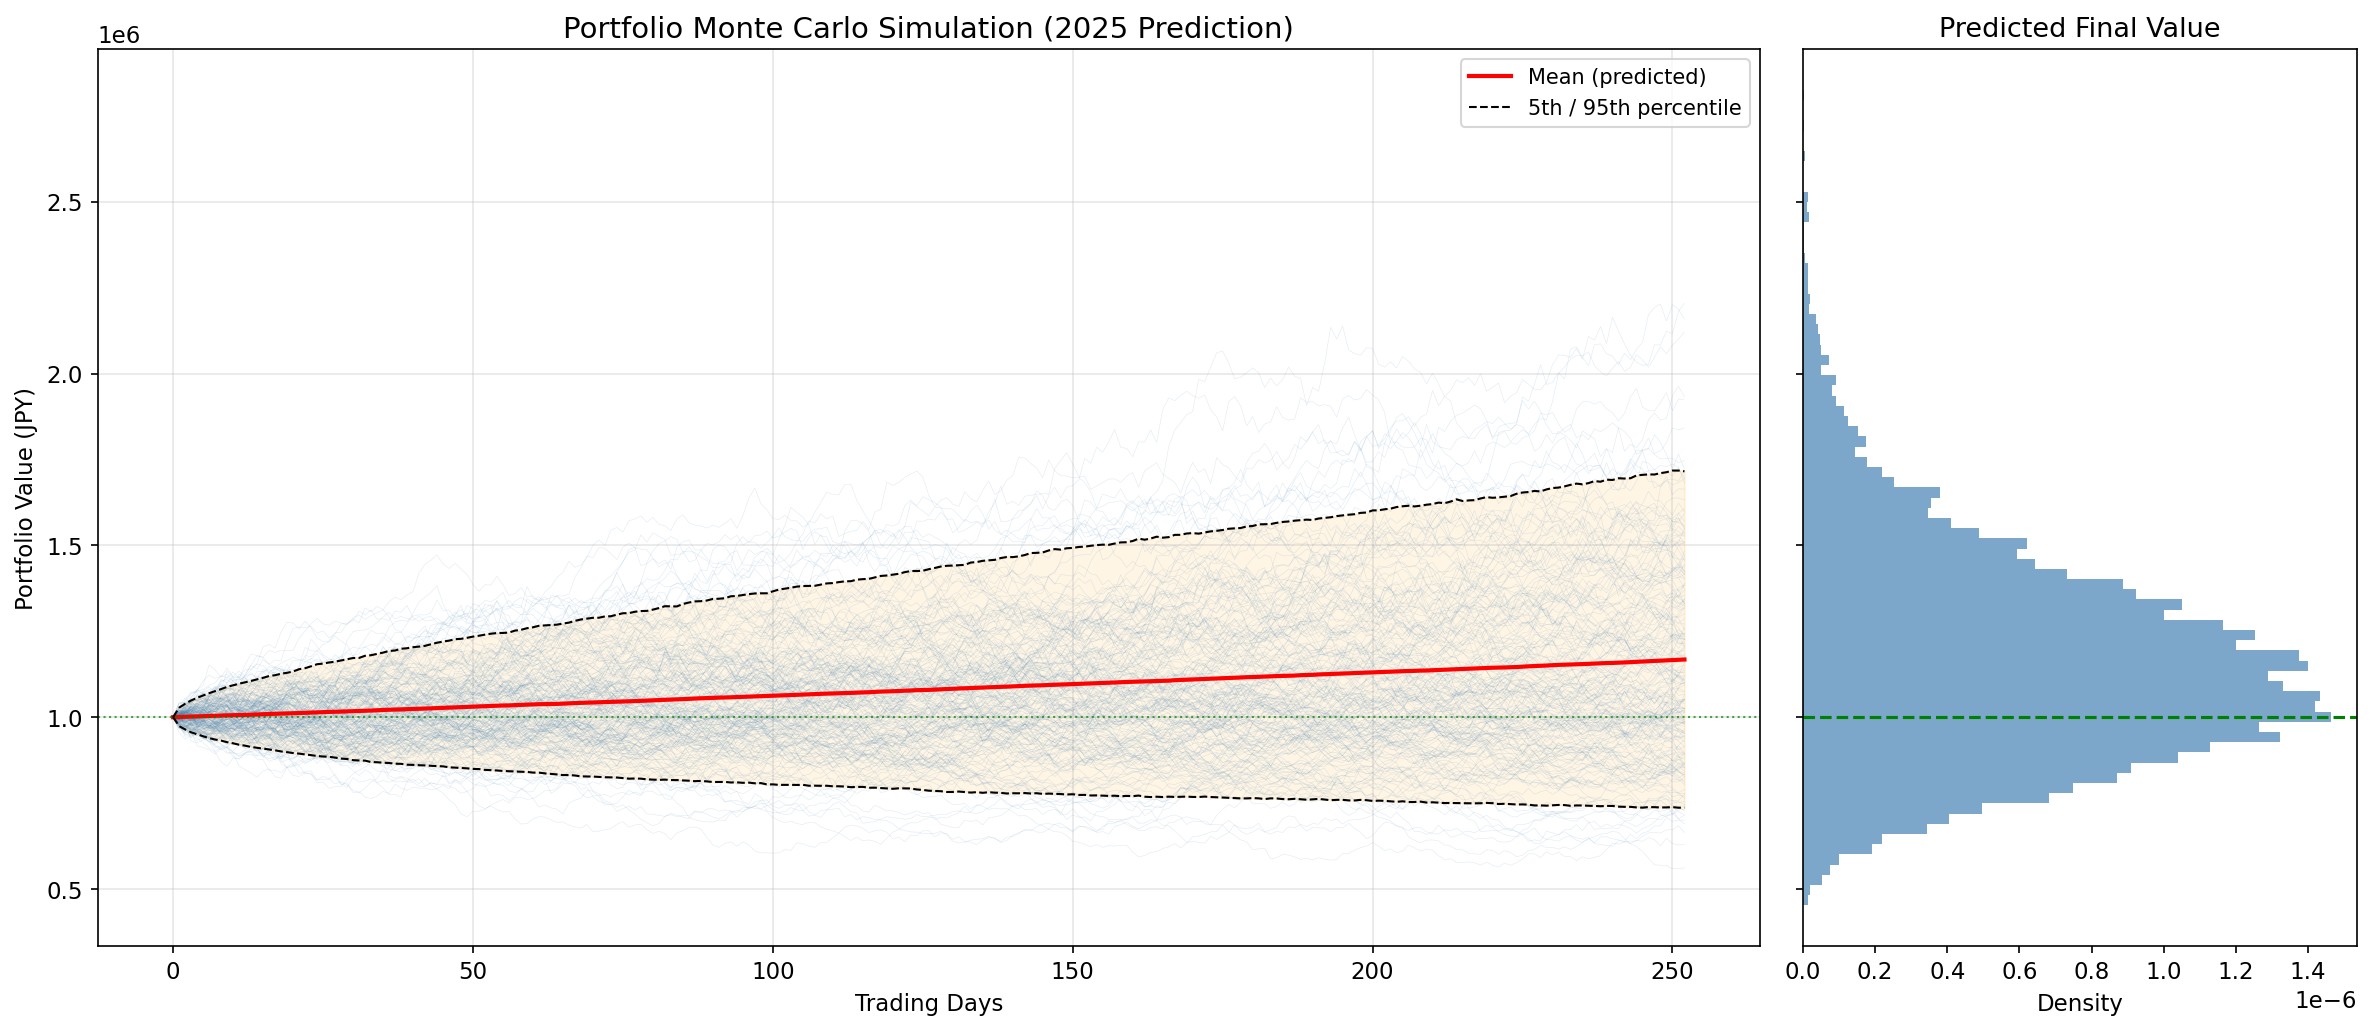

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [3, 1]}, sharey=True)
t_axis = np.arange(n_days + 1)
for i in range(200):
    axes[0].plot(t_axis, portfolio_values[:, i], linewidth=0.3, alpha=0.15, color='steelblue')
p5 = np.percentile(portfolio_values, 5, axis=1)
p95 = np.percentile(portfolio_values, 95, axis=1)
mean_path = portfolio_values.mean(axis=1)
axes[0].plot(t_axis, mean_path, 'r-', linewidth=2, label='Mean (predicted)')
axes[0].plot(t_axis, p5, 'k--', linewidth=1, label='5th / 95th percentile')
axes[0].plot(t_axis, p95, 'k--', linewidth=1)
axes[0].fill_between(t_axis, p5, p95, alpha=0.1, color='orange')
axes[0].axhline(y=investment, color='green', linestyle=':', linewidth=1, alpha=0.7)
axes[0].set_title('Portfolio Monte Carlo Simulation (2025 Prediction)', fontsize=14)
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value (JPY)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[1].hist(portfolio_values[-1], bins=80, orientation='horizontal', density=True,
             alpha=0.7, color='steelblue', edgecolor='none')
axes[1].axhline(y=investment, color='green', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Density')
axes[1].set_title('Predicted Final Value', fontsize=13)
plt.tight_layout()
plt.show()

## 6. プットオプションでヘッジ（ブラックショールズ）

In [11]:
def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

S_port = investment
K_put = investment * 0.90
T_put = 1.0
port_sigma = opt_vol
put_cost = bs_put(S_port, K_put, T_put, rf_annual, port_sigma)

print("=== プロテクティブプットのコスト ===")
print(f"行使価格: {K_put:,.0f}円 (10%下落水準)")
print(f"プット価格: {put_cost:,.0f}円 ({put_cost/investment*100:.2f}%)")

hedged_values = np.maximum(portfolio_values[-1], K_put) - put_cost
unhedged_values = portfolio_values[-1]
hedged_returns = hedged_values / investment - 1
unhedged_returns = unhedged_values / investment - 1
var_unhedged = -np.percentile(unhedged_returns, 5)
var_hedged = -np.percentile(hedged_returns, 5)

print(f"\n=== ヘッジ効果 ===")
print(f"  VaR (unhedged): {var_unhedged*100:.2f}%")
print(f"  VaR (hedged):   {var_hedged*100:.2f}%")

=== プロテクティブプットのコスト ===
行使価格: 900,000円 (10%下落水準)
プット価格: 48,443円 (4.84%)

=== ヘッジ効果 ===
  VaR (unhedged): 26.32%
  VaR (hedged):   14.84%


### 図3: ヘッジあり/なしの比較

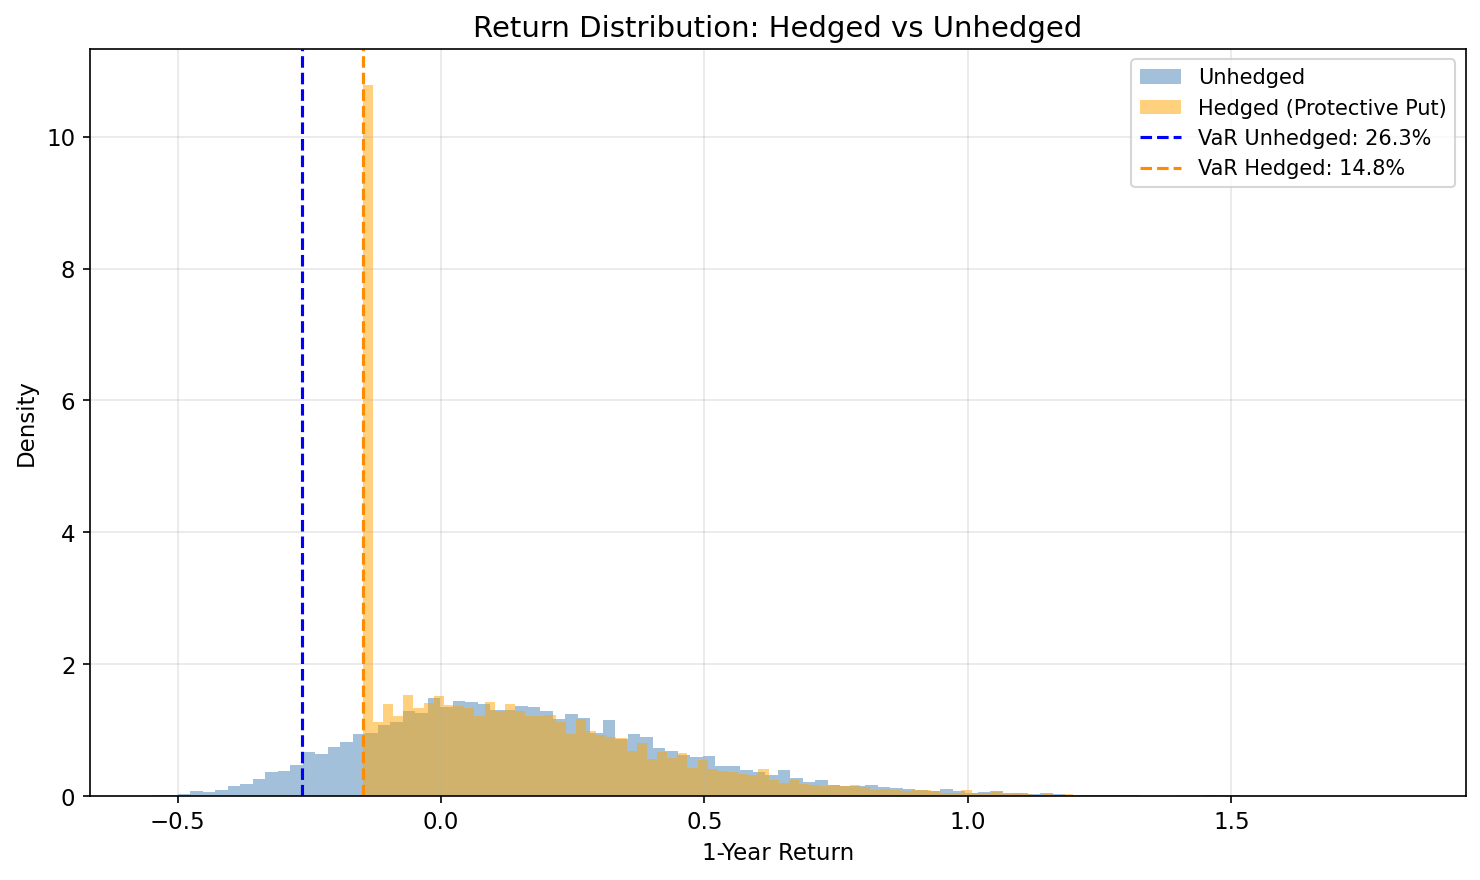

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(unhedged_returns, bins=100, density=True, alpha=0.5, color='steelblue',
        edgecolor='none', label='Unhedged')
ax.hist(hedged_returns, bins=100, density=True, alpha=0.5, color='orange',
        edgecolor='none', label='Hedged (Protective Put)')
ax.axvline(x=-var_unhedged, color='blue', linestyle='--', linewidth=1.5,
           label=f'VaR Unhedged: {var_unhedged*100:.1f}%')
ax.axvline(x=-var_hedged, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'VaR Hedged: {var_hedged*100:.1f}%')
ax.set_title('Return Distribution: Hedged vs Unhedged', fontsize=14)
ax.set_xlabel('1-Year Return')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 答え合わせ: 2025年の実データで検証

In [13]:
test_prices = test_data[tickers]
test_returns = test_prices.pct_change().dropna()
port_daily_returns = (test_returns * optimal_weights).sum(axis=1)
port_cumulative = (1 + port_daily_returns).cumprod() * investment

actual_final = port_cumulative.iloc[-1]
actual_return = actual_final / investment - 1

print("=== 2025年 実績 ===")
print(f"最終ポートフォリオ価値: {actual_final:,.0f}円")
print(f"リターン: {actual_return*100:.2f}%")
print()
percentile = np.mean(portfolio_values[-1] <= actual_final) * 100
print(f"実績はMC分布の{percentile:.1f}パーセンタイルに位置")
print()
print("=== 各銘柄の2025年実績 ===")
for ticker in tickers:
    s = test_prices[ticker].iloc[0]
    e = test_prices[ticker].iloc[-1]
    print(f"  {ticker}: ${s:.2f} -> ${e:.2f} ({(e/s-1)*100:+.2f}%)")

=== 2025年 実績 ===
最終ポートフォリオ価値: 1,267,216円
リターン: 26.72%

実績はMC分布の67.0パーセンタイルに位置

=== 各銘柄の2025年実績 ===
  AAPL: $242.53 -> $272.82 (+12.49%)
  MSFT: $414.57 -> $486.37 (+17.32%)
  AMZN: $220.22 -> $232.53 (+5.59%)
  JPM: $232.78 -> $320.33 (+37.61%)
  JNJ: $139.00 -> $205.82 (+48.07%)


### 図4: シミュレーション予測 vs 2025年実績（メインビジュアル）

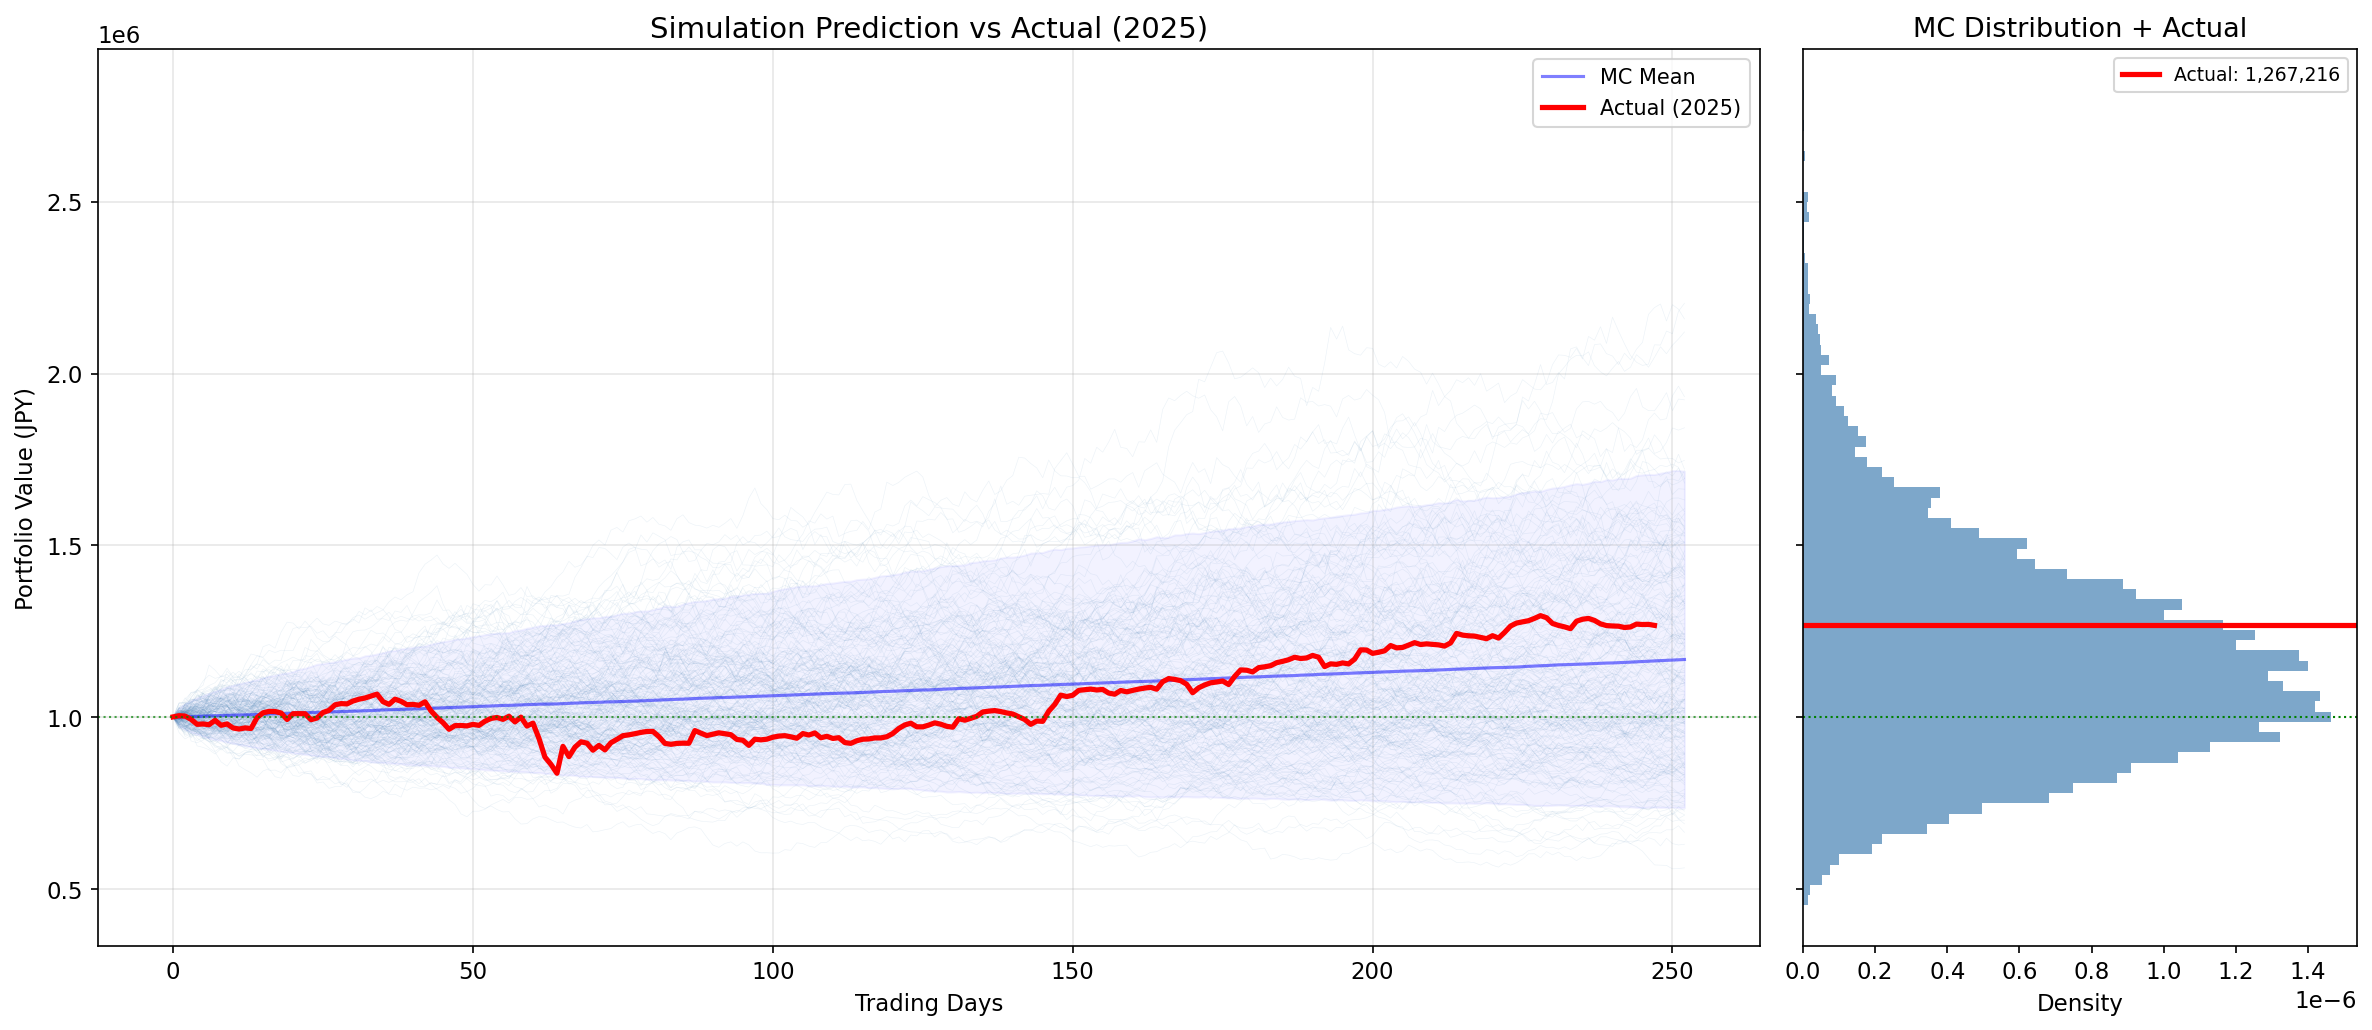

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [3, 1]}, sharey=True)

t_axis_sim = np.arange(n_days + 1)
n_test_days = len(port_cumulative)
t_axis_actual = np.arange(n_test_days)

for i in range(200):
    axes[0].plot(t_axis_sim, portfolio_values[:, i], linewidth=0.3, alpha=0.1, color='steelblue')

axes[0].plot(t_axis_sim, mean_path, 'b-', linewidth=1.5, alpha=0.5, label='MC Mean')
axes[0].fill_between(t_axis_sim, p5, p95, alpha=0.05, color='blue')
axes[0].plot(t_axis_actual, port_cumulative.values, 'r-', linewidth=2.5, label='Actual (2025)')
axes[0].axhline(y=investment, color='green', linestyle=':', linewidth=1, alpha=0.7)

axes[0].set_title('Simulation Prediction vs Actual (2025)', fontsize=14)
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value (JPY)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].hist(portfolio_values[-1], bins=80, orientation='horizontal', density=True,
             alpha=0.7, color='steelblue', edgecolor='none')
axes[1].axhline(y=actual_final, color='red', linestyle='-', linewidth=2.5,
                label=f'Actual: {actual_final:,.0f}')
axes[1].axhline(y=investment, color='green', linestyle=':', linewidth=1)
axes[1].set_xlabel('Density')
axes[1].set_title('MC Distribution + Actual', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# 2025年の実データによるポートフォリオ推移
test_prices = test_data[tickers]
test_returns = test_prices.pct_change().dropna()

# 最適ウェイトで組んだポートフォリオの日次リターン
port_daily_returns = (test_returns * optimal_weights).sum(axis=1)
port_cumulative = (1 + port_daily_returns).cumprod() * investment

# 実績値
actual_final = port_cumulative.iloc[-1]
actual_return = actual_final / investment - 1

print("=== 2025年 実績 ===")
print(f"最終ポートフォリオ価値: {actual_final:,.0f}円")
print(f"リターン: {actual_return*100:.2f}%")
print(f"")
print("=== シミュレーション予測との比較 ===")
print(f"MC予測 平均: {portfolio_values[-1].mean():,.0f}円")
print(f"MC予測 中央値: {np.median(portfolio_values[-1]):,.0f}円")
print(f"実績: {actual_final:,.0f}円")
print(f"")
percentile = np.mean(portfolio_values[-1] <= actual_final) * 100
print(f"実績はMC分布の{percentile:.1f}パーセンタイルに位置")

=== 2025年 実績 ===
最終ポートフォリオ価値: 1,267,216円
リターン: 26.72%

=== シミュレーション予測との比較 ===
MC予測 平均: 1,167,913円
MC予測 中央値: 1,136,147円
実績: 1,267,216円

実績はMC分布の67.0パーセンタイルに位置
